In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [5]:
df = pd.read_csv("청년정책목록_전체.csv", encoding="utf-8")

# 정책 설명

In [7]:
# 정책명, 정책설명내용, 정책지원내용, 정책대분류명, 정책중분류명, 정책키워드명, 참고URL주소1, 참고URL주소2, 심사방법내용, 기타사항내용

In [26]:
df_description = df[['plcyNm', 'plcyExplnCn', 'plcySprtCn', 'lclsfNm', 'mclsfNm', 'plcyKywdNm', 'refUrlAddr1', 'refUrlAddr2', 'srngMthdCn', 'etcMttrCn']]

# 컬럼 이름 변경
df_description.columns = ['정책명', '정책설명', '지원내용', '대분류', '중분류', '키워드', 'URL1', 'URL2', '심사방법', '기타사항']

df_description.head(3)

,정책명,정책설명,지원내용,대분류,중분류,키워드,URL1,URL2,심사방법,기타사항
0,주거안정장학금,원거리 대학 진학으로 인해 주거 관련 비용 부담이 큰 저소득 대학생을 대상으로 주거...,"□ 지원금액: 월 최대 20만 원\n※ 단, 방학 중(7~8월, 1~2월)에는 지원...",교육,교육비지원,"보조금,교육지원",https://www.kosaf.go.kr/ko/scholar.do?pg=schol...,NaN,□ 선발결과 공개일: 10월 4 ~ 5주 예정\n- 선발결과 공개일은 재단 및 유관...,NaN
1,부산 청년돌봄이음,고립·은둔 청년 및 가족돌봄 청(소)년 지원,"1. 청년 돌봄이음 시범사업(제공기관 : 종합사회복지관) : 초기상담, 성장 계획 ...",복지문화,취약계층 및 금융지원,바우처,NaN,NaN,NaN,NaN
2,서울 청년 마음건강 지원사업,우울·불안 등 정서적 어려움을 겪는 청년의 마음건강 회복,ㅇ (사업 내용) 2단계 선별검사로 과학적 진단을 통한 맞춤형 상담 지원\n ...,복지문화,건강,맞춤형상담서비스,https://youth.seoul.go.kr/youthConts.do?key=23...,NaN,NaN,ㅇ (사업 근거)\n - 청년기본법 제21조(청년 복지증진)\n - 서울특별...


In [27]:
# 결측치
df_description.isnull().sum().sort_values(ascending=False)

URL2    2922
키워드     2502
심사방법    1414
기타사항    1283
URL1     901
대분류       37
중분류       37
정책명        0
정책설명       0
지원내용       0
dtype: int64

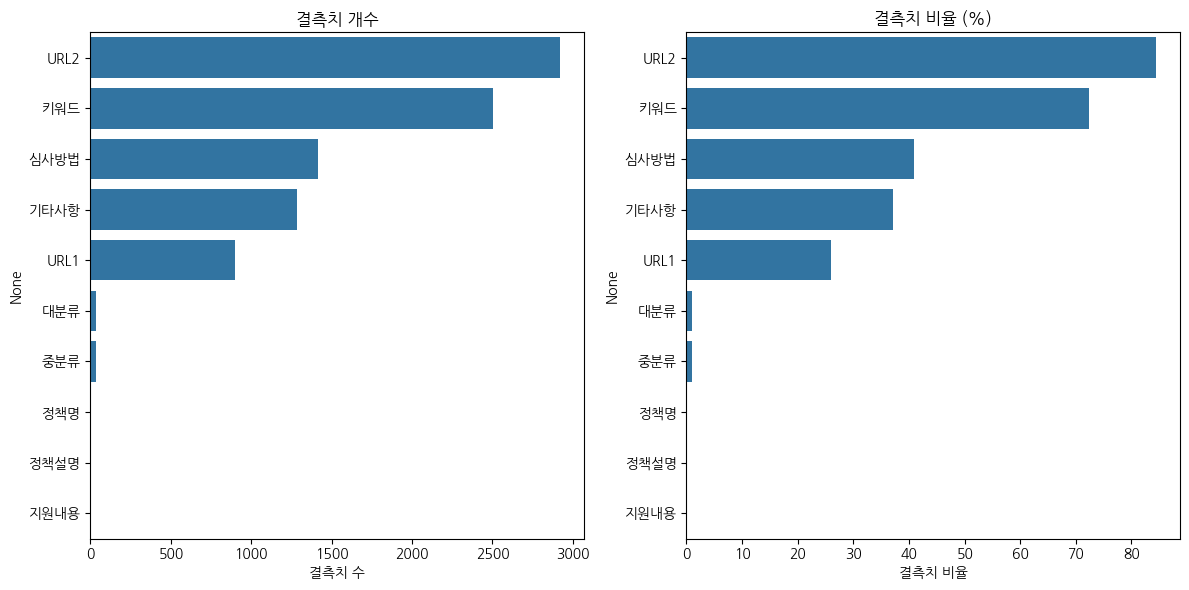

In [51]:
# 결측치 개수 계산
missing_values = df_description.isnull().sum().sort_values(ascending=False)

# 결측치 비율 계산
missing_percentage = (df_description.isnull().sum() / len(df_description) * 100).sort_values(ascending=False)

# 그래프 크기 설정
plt.figure(figsize=(12, 6))

# 결측치 개수 시각화
plt.subplot(1, 2, 1)
sns.barplot(x=missing_values.values, y=missing_values.index)
plt.title('결측치 개수')
plt.xlabel('결측치 수')

# 결측치 비율 시각화
plt.subplot(1, 2, 2)
sns.barplot(x=missing_percentage.values, y=missing_percentage.index)
plt.title('결측치 비율 (%)')
plt.xlabel('결측치 비율')

plt.tight_layout()
plt.show()

## URL

In [30]:
# URL1과 URL2가 모두 결측치가 아니고 동일한 값을 가진 데이터 확인
same_urls = df_description[(df_description['URL1'].notna()) & 
                          (df_description['URL2'].notna()) & 
                          (df_description['URL1'] == df_description['URL2'])]

# 동일한 URL의 개수
same_urls_count = len(same_urls)

print(f"URL1과 URL2가 동일한 데이터 수: {same_urls_count}개")


URL1과 URL2가 동일한 데이터 수: 4개


In [31]:
# URL2는 결측치가 아니고 URL1은 결측치인 데이터 확인
missing_url1 = df_description[(df_description['URL1'].isna()) & 
                               (df_description['URL2'].notna())]
# 결측치가 아닌 URL2의 개수
missing_url1_count = len(missing_url1)
print(f"URL1이 결측치이고 URL2가 결측치가 아닌 데이터 수: {missing_url1_count}개")

URL1이 결측치이고 URL2가 결측치가 아닌 데이터 수: 3개


In [32]:
# URL1은 결측치가 아니고 URL2는 결측치인 데이터 확인
missing_url2 = df_description[(df_description['URL1'].notna()) & 
                               (df_description['URL2'].isna())]
# 결측치가 아닌 URL1의 개수
missing_url2_count = len(missing_url2)
print(f"URL1이 결측치가 아니고 URL2가 결측치인 데이터 수: {missing_url2_count}개")

URL1이 결측치가 아니고 URL2가 결측치인 데이터 수: 2024개


URL1과 URL2의 데이터가 같지 않을 때 URL2의 데이터를 URL1로 추가한다

## 대분류, 중분류, 키워드

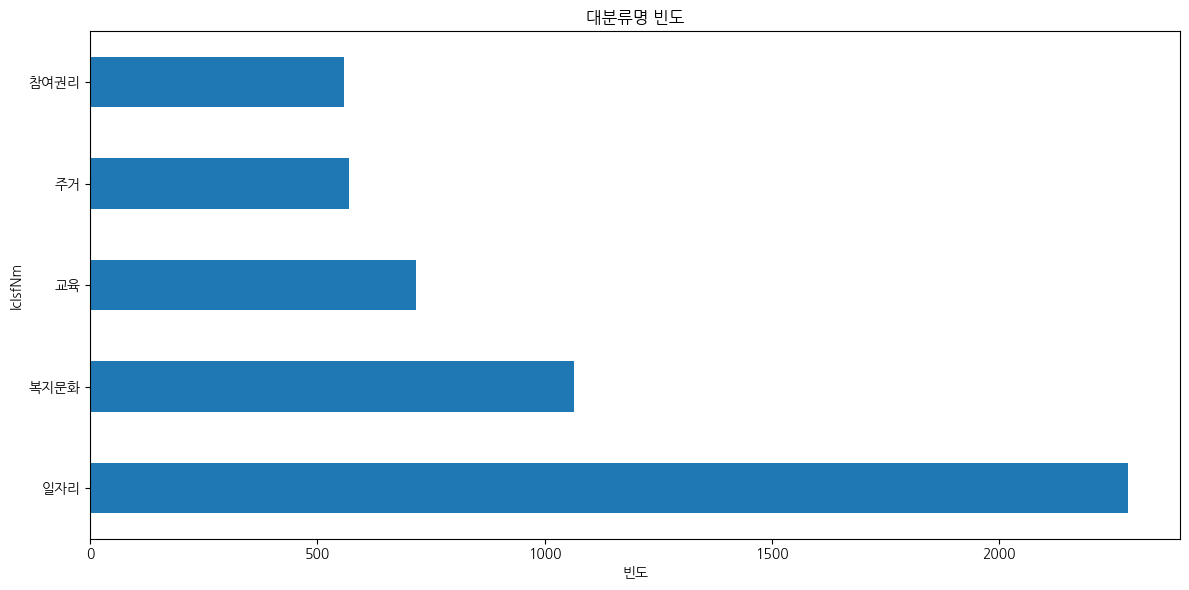

In [37]:
# 쉼표로 분리하여 대분류명 카운트
all_keywords = df['lclsfNm'].dropna().str.split(',').explode().str.strip()
keyword_counts = all_keywords.value_counts()

# 시각화
plt.figure(figsize=(12, 6))
keyword_counts.head(15).plot(kind='barh')
plt.title('대분류명 빈도')
plt.xlabel('빈도')
plt.tight_layout()
plt.show()

In [101]:
print(df_description[df_description['대분류']=='참여권리'][['중분류', '키워드']].value_counts())

중분류      키워드                                      
청년참여     교육지원                                         14
청년국제교류   해외진출                                         12
청년참여     맞춤형상담서비스                                      5
정책인프라구축  보조금                                           4
         교육지원                                          4
         맞춤형상담서비스                                      3
         벤처                                            3
청년참여     보조금                                           3
         인턴                                            3
         청년가장                                          2
         맞춤형상담서비스,보조금                                  2
권익보호     장기미취업청년                                       2
         교육지원                                          2
         벤처                                            1
         신용회복,청년가장,맞춤형상담서비스,장기미취업청년,중소기업,출산,공공임대주택     1
청년국제교류   보조금                                           1
정책인프라구축  출산                          

In [ ]:
df_su

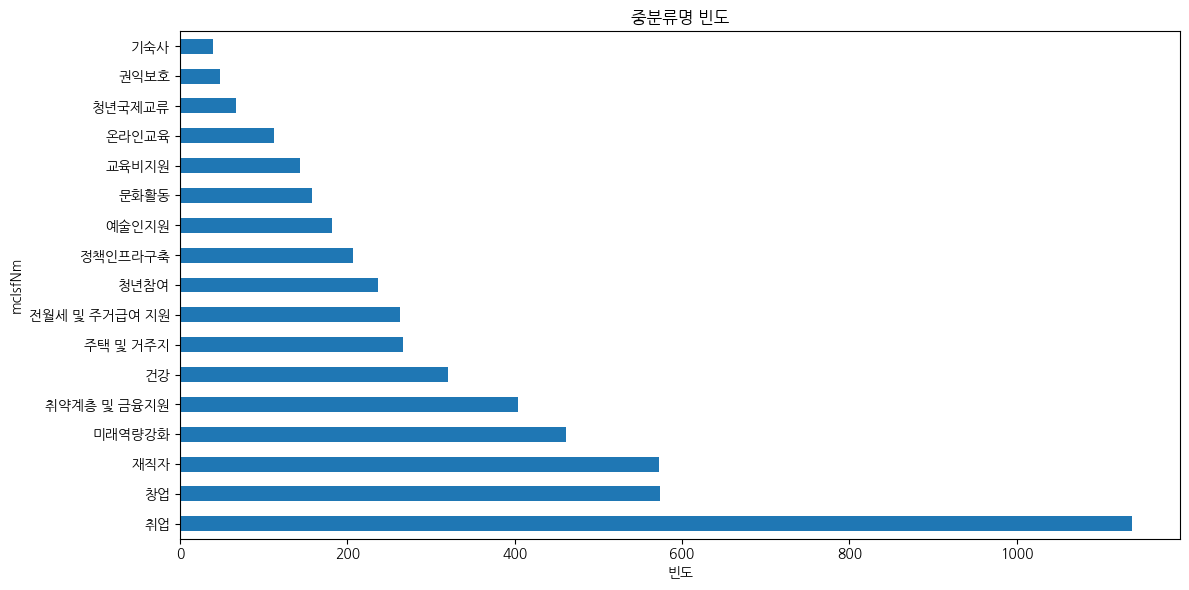

중분류 총 17개


In [40]:
# 쉼표로 분리하여 중분류명 카운트
all_keywords = df['mclsfNm'].dropna().str.split(',').explode().str.strip()
keyword_counts = all_keywords.value_counts()

# 시각화
plt.figure(figsize=(12, 6))
keyword_counts.plot(kind='barh')
plt.title('중분류명 빈도')
plt.xlabel('빈도')
plt.tight_layout()
plt.show()

print("중분류 총 17개")

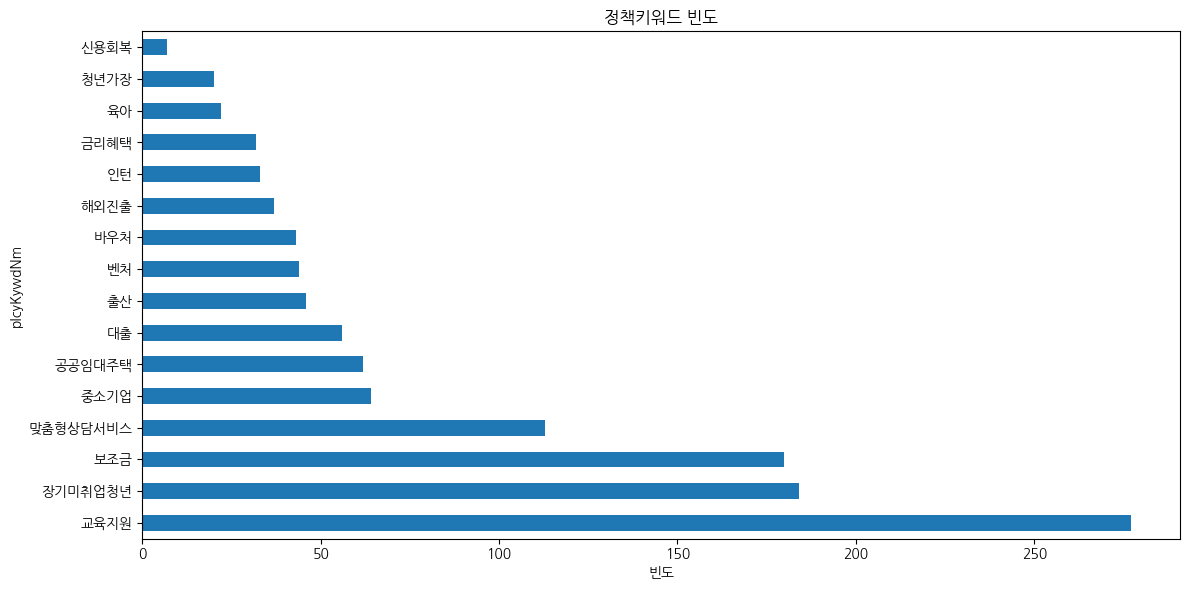

정책 키워드 총 16개


In [36]:
# 쉼표로 분리하여 키워드 카운트
all_keywords = df['plcyKywdNm'].dropna().str.split(',').explode().str.strip()
keyword_counts = all_keywords.value_counts().sort_values(ascending=False)

# 키워드 총 16개
plt.figure(figsize=(12, 6))
keyword_counts.plot(kind='barh')
plt.title('정책키워드 빈도')
plt.xlabel('빈도')
plt.tight_layout()
plt.show()

print("정책 키워드 총 16개")

키워드의 결측치 비율이 높고 중분류와 키워드 데이터 성격이 비슷해 하나로 합친다

# 정책 신청

In [43]:
# 신청기간, 신청URL주소, 정책신청방법내용, 제출서류내용
df_application = df[['aplyYmd', 'aplyUrlAddr', 'plcyAplyMthdCn', 'sbmsnDcmntCn']]
# 컬럼 이름 변경
df_application.columns = ['신청기간', '신청URL', '신청방법', '제출서류']

df_application.head(3)

,신청기간,신청URL,신청방법,제출서류
0,20250523 ~ 20250623,https://www.kosaf.go.kr/ko/scholar.do?pg=schol...,□ 2학기 신청일정: 2025. 5. 23.(금) 9시 ~ 6. 23.(월) 18시...,한국장학재단 홈페이지(https://www.kosaf.go.kr/ko/scholar...
1,NaN,https://busan.pass.or.kr/support/sub6.php,부산사회서비스원 홈페이지온라인 신청\n○ 고립은둔 청년 지원 신청 : https:/...,"대상자 선정을 위해 필요한 추가서류 요청\n\n가족돌봄 청(소)년의 경우,\n① (..."
2,20250201 ~ 20250930\N20250414 ~ 20250417,NaN,"총 4차(1월, 4월, 6월, 9월)에 걸쳐 참여자를 모집하며, 연도내 중복참여는 ...",NaN


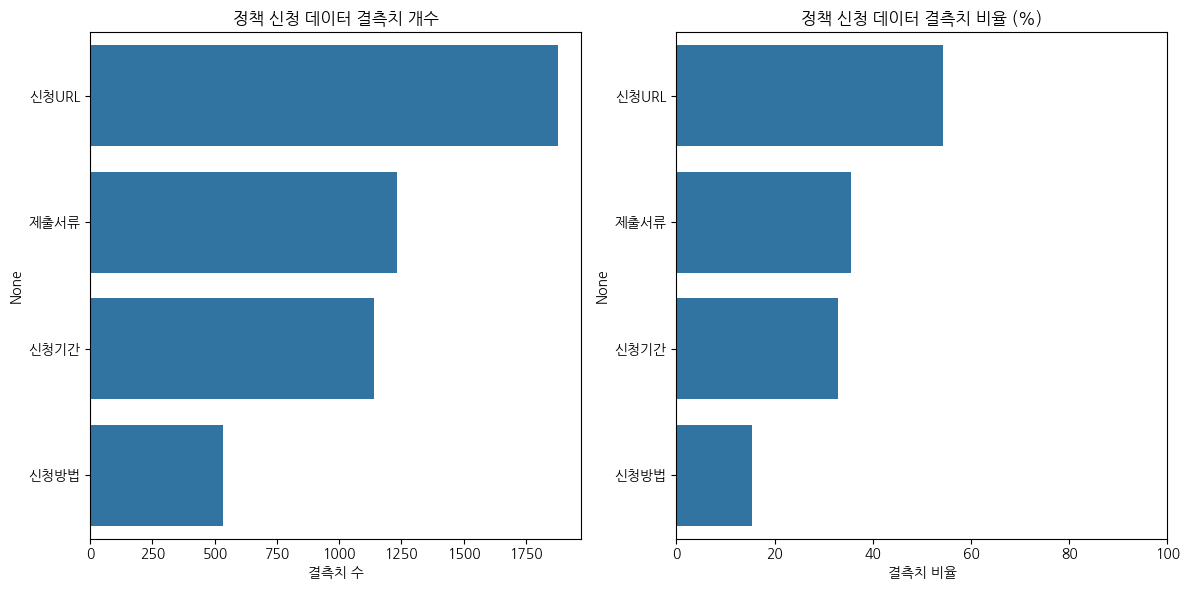

신청기간: 1139개 (32.94%)
신청URL: 1879개 (54.34%)
신청방법: 532개 (15.38%)
제출서류: 1232개 (35.63%)


In [52]:
# df_application 결측치 시각화
# 결측치 개수 계산
missing_values = df_application.isnull().sum().sort_values(ascending=False)

# 결측치 비율 계산
missing_percentage = (df_application.isnull().sum() / len(df_application) * 100).sort_values(ascending=False)

# 그래프 크기 설정
plt.figure(figsize=(12, 6))

# 결측치 개수 시각화
plt.subplot(1, 2, 1)
sns.barplot(x=missing_values.values, y=missing_values.index)
plt.title('정책 신청 데이터 결측치 개수')
plt.xlabel('결측치 수')

# 결측치 비율 시각화
plt.subplot(1, 2, 2)
sns.barplot(x=missing_percentage.values, y=missing_percentage.index)
plt.title('정책 신청 데이터 결측치 비율 (%)')
plt.xlabel('결측치 비율')
plt.xlim(0, 100)  # x축 범위를 0부터 100까지 설정

plt.tight_layout()
plt.show()

# 결측치 수와 비율 출력
for column in df_application.columns:
    null_count = df_application[column].isnull().sum()
    null_percent = (null_count / len(df_application)) * 100
    print(f"{column}: {null_count}개 ({null_percent:.2f}%)")

## 신청URL

In [ ]:
# 가설1: 신청URL 주소가 결측치인 경우 오프라인 신청방법일 것이다.
df_application[df_application['신청URL'].isnull()]
# 가설 거짓

,신청기간,신청URL,신청방법,제출서류
2,20250201 ~ 20250930\N20250414 ~ 20250417,NaN,"총 4차(1월, 4월, 6월, 9월)에 걸쳐 참여자를 모집하며, 연도내 중복참여는 ...",NaN
5,20250528 ~ 20250528,NaN,□ 신청일시 : 2025. 5. 28.(수) 10:00 ~ \n※ 선착순 선정\n\...,NaN
6,NaN,NaN,부산청년플랫폼 온라인 신청,NaN
8,20250526 ~ 20250531,NaN,□ 신청방법 : 부산청년플랫폼(https://young.busan.go.kr/ind...,NaN
10,20250304 ~ 20250630,NaN,□ 방문신청 : 신청자 주민등록상 주소지 관할 시·군 읍·면·동 주민센터 평일 근무...,① 신청서 1부\n② 개인정보동의서 1부\n③ 주민등록초본 1부\n④ 건강보험자격득...
...,...,...,...,...
3442,20231222 ~ 20240119,NaN,이메일 접수(ktcc_hansik@naver.com),"□ 지원신청서(영업허가증, 사업등록증 첨부)\n□ 디저트 개발 계획서\n□ 개인(기..."
3443,20240104 ~ 20240202,NaN,방문접수 : 밀양시청 4층 일자리경제과 에너지관리담당,□ 한전 생활관 이용신청서 1부.\n□ 주민등록 등본 원본 1부.(학생 타지역인 경...
3445,NaN,NaN,□ 신청방법: 해당 주소지 관할 읍면동 주민센터 방문 신청\n□ 신청자 : 지원 대...,□ 대학교 신입생 장학금 신청서\n□ 개인정보활용동의서\n□ 등본(최근 5년간 주소...
3446,NaN,NaN,주소지 관할 읍면동 주민센터 방문,-


## 신청기간

In [67]:
# 가설1: 신청기간이 결측치인 경우 상시 신청할 수 있는 정책일 것이다.
df[df_application['신청기간'].isnull()]['aplyPrdSeCd']

1       57002
6       57002
7       57002
16      57002
18      57002
        ...  
3452    57003
3453    57003
3454    57003
3455    57003
3456    57003
Name: aplyPrdSeCd, Length: 1139, dtype: int64

In [68]:
df[df_application['신청기간'].isnull()]['aplyPrdSeCd'].value_counts()

aplyPrdSeCd
57003    847
57002    291
57001      1
Name: count, dtype: int64

판단X

# 지원자격

In [ ]:
# 지원도착순서여부, 지원대상최소연령, 지원대상최대연령, 지원대상연령제한여부
# 소득최소금액, 소득최대금액, 소득기타내용
# 정책거주지역코드, 정책전공요건코드, 정책취업요건코드, 정책학력요건코드

In [71]:
df_support = df[['sprtArvlSeqYn', 'sprtTrgtMinAge', 'sprtTrgtMaxAge', 'sprtTrgtAgeLmtYn',
                'earnMinAmt', 'earnMaxAmt', 'earnEtcCn',
                'zipCd', 'plcyMajorCd', 'jobCd', 'schoolCd']]

df_support.columns = ['도착순서여부', '최소연령', '최대연령', '연령제한여부',
                    '최소소득', '최대소득', '기타소득', 
                    '거주지역코드', '전공요건코드', '취업요건코드', '학력요건코드']

df_support.head(3)

,도착순서여부,최소연령,최대연령,연령제한여부,최소소득,최대소득,기타소득,거주지역코드,전공요건코드,취업요건코드,학력요건코드
0,N,0.0,39.0,N,0.0,0.0,기초생활수급자 또는 차상위계층,"11110,11140,11170,11200,11215,11230,11260,1129...",0011009,0013010,0049005
1,N,18.0,39.0,N,0.0,0.0,신청페이지 상세안내 확인,"26110,26140,26170,26200,26230,26260,26290,2632...",0011009,0013010,0049010
2,N,19.0,39.0,N,0.0,0.0,NaN,"11110,11140,11170,11200,11215,11230,11260,1129...",0011009,0013010,0049010


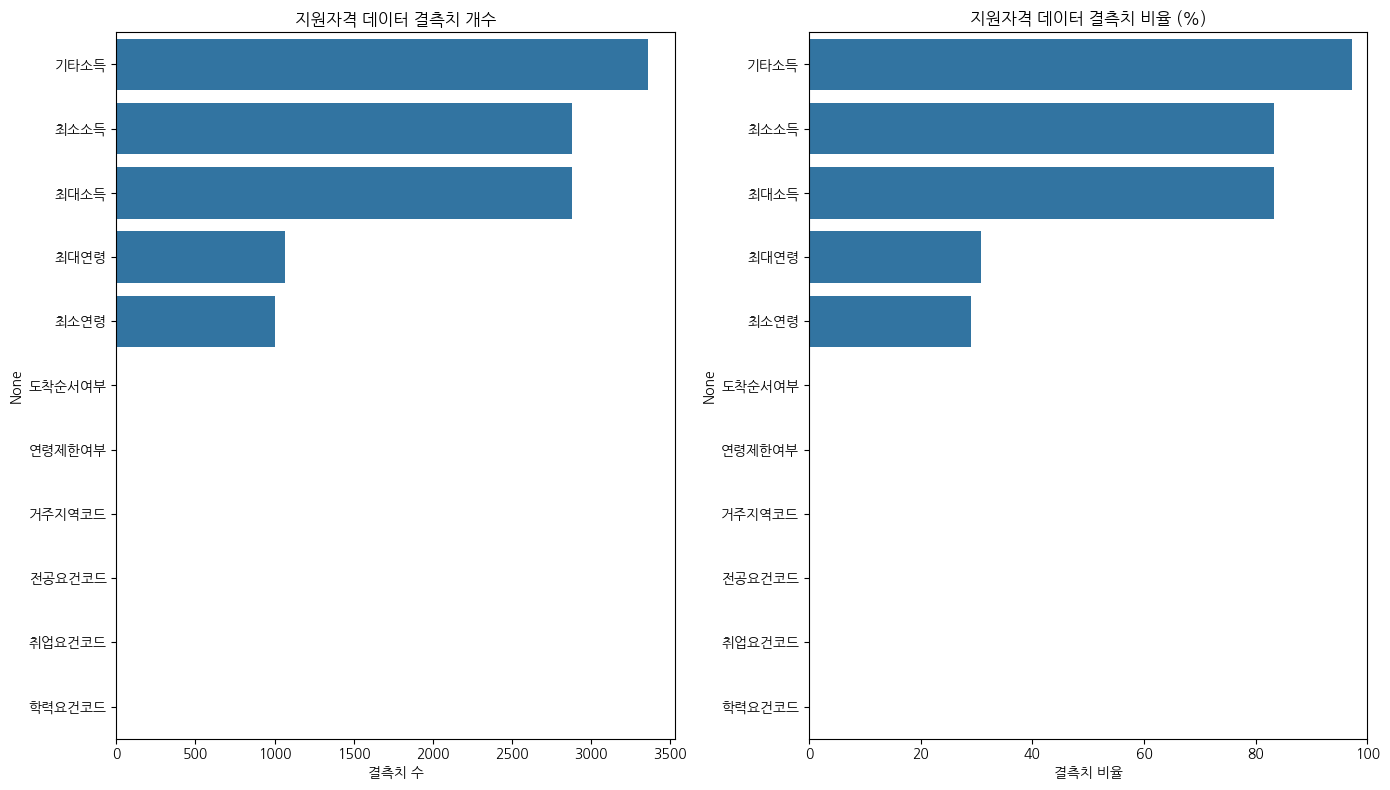

지원자격 데이터 결측치 정보:
도착순서여부: 0개 (0.00%)
최소연령: 1005개 (29.06%)
최대연령: 1068개 (30.88%)
연령제한여부: 0개 (0.00%)
최소소득: 2878개 (83.23%)
최대소득: 2878개 (83.23%)
기타소득: 3361개 (97.19%)
거주지역코드: 0개 (0.00%)
전공요건코드: 0개 (0.00%)
취업요건코드: 0개 (0.00%)
학력요건코드: 0개 (0.00%)


In [72]:
# df_support 결측치 시각화
# 결측치 개수 계산
missing_values = df_support.isnull().sum().sort_values(ascending=False)

# 결측치 비율 계산
missing_percentage = (df_support.isnull().sum() / len(df_support) * 100).sort_values(ascending=False)

# 그래프 크기 설정
plt.figure(figsize=(14, 8))

# 결측치 개수 시각화
plt.subplot(1, 2, 1)
sns.barplot(x=missing_values.values, y=missing_values.index)
plt.title('지원자격 데이터 결측치 개수')
plt.xlabel('결측치 수')

# 결측치 비율 시각화
plt.subplot(1, 2, 2)
sns.barplot(x=missing_percentage.values, y=missing_percentage.index)
plt.title('지원자격 데이터 결측치 비율 (%)')
plt.xlabel('결측치 비율')
plt.xlim(0, 100)  # x축 범위를 0부터 100까지 설정

plt.tight_layout()
plt.show()

# 결측치 수와 비율 출력
print("지원자격 데이터 결측치 정보:")
for column in df_support.columns:
    null_count = df_support[column].isnull().sum()
    null_percent = (null_count / len(df_support)) * 100
    print(f"{column}: {null_count}개 ({null_percent:.2f}%)")

## 소득


In [76]:
# 가설1: 최소소득이 결측치인 경우 최대소득도 결측치이다.
df_support[df_support['최소소득'].isnull() & df_support['최대소득'].notnull()]
# 가설 참

,도착순서여부,최소연령,최대연령,연령제한여부,최소소득,최대소득,기타소득,거주지역코드,전공요건코드,취업요건코드,학력요건코드


In [77]:
# 가설2: 최대소득이 결측치인 경우 최소소득도 결측치이다.
df_support[df_support['최대소득'].isnull() & df_support['최소소득'].notnull()]
# 가설 참

,도착순서여부,최소연령,최대연령,연령제한여부,최소소득,최대소득,기타소득,거주지역코드,전공요건코드,취업요건코드,학력요건코드


In [ ]:
# 가설3: 최소소득, 최대소득이 결측치인 경우 기타소득도 결측치이다.
df_support[df_support['최소소득'].isnull() & df_support['최대소득'].isnull() & df_support['기타소득'].notnull()].head(3)
# 가설 거짓

,도착순서여부,최소연령,최대연령,연령제한여부,최소소득,최대소득,기타소득,거주지역코드,전공요건코드,취업요건코드,학력요건코드
1024,N,18.0,49.0,N,NaN,NaN,중위소득 산정이 가능한 자 ~ 중위소득 150%이하,46820,0011009,"0013001,0013002,0013003,0013004,0013005,001300...",0049010
1106,N,NaN,NaN,Y,NaN,NaN,출산가구 합산 기준중위소득 180% 이하,43000,0011009,0013010,0049010
1107,N,19.0,39.0,N,NaN,NaN,주민등록상 도내 거주하는 합산 기준중위소득 180%이하 (청년 신혼부부),43000,0011009,0013010,0049010


In [83]:
# 최소소득, 최대소득이 결측치인 경우 기타소득이 결측치가 아닌 경우의 개수
len(df_support[df_support['최소소득'].isnull() & df_support['최대소득'].isnull() & df_support['기타소득'].notnull()])

14

In [84]:
# 가설4: 소득 데이터가 없는 경우, 소득제한이 없는 정책이다.
df_support[df_support['최소소득'].isnull() & df_support['최대소득'].isnull() & df_support['기타소득'].isnull()].head(3)

,도착순서여부,최소연령,최대연령,연령제한여부,최소소득,최대소득,기타소득,거주지역코드,전공요건코드,취업요건코드,학력요건코드
580,N,NaN,NaN,Y,NaN,NaN,NaN,"11110,11140,11170,11200,11215,11230,11260,1129...",0011009,0013010,0049010
581,N,NaN,NaN,Y,NaN,NaN,NaN,11740,0011009,0013010,0049010
582,N,NaN,NaN,Y,NaN,NaN,NaN,"11110,11140,11170,11200,11215,11230,11260,1129...",0011009,0013010,0049010


In [ ]:
# 가설 거짓
df.iloc[580]

plcyNo                                            20241111005400100005
bscPlanCycl                                                          1
bscPlanPlcyWayNo                                                     4
bscPlanFcsAsmtNo                                                    16
bscPlanAsmtNo                                                       43
pvsnInstGroupCd                                                  54001
plcyPvsnMthdCd                                                     NaN
plcyAprvSttsCd                                                   44002
plcyNm                                          2024년 근로 자녀장려금 기한 후 신청
plcyKywdNm                                                         NaN
plcyExplnCn          ○ 근로장려금 이란?\n소득과 재산이 일정 금액 미만인 근로자, 종교인 또는 사업자...
lclsfNm                                                           복지문화
mclsfNm                                                          예술인지원
plcySprtCn           ○ 근로장려금\n○ 자녀장려금\n※ 자세한 사항은 홈페이지 안내문 내 '지급액 산정...
sprvsn

## 연령데이터

In [88]:
# 가설1: 최소연령이 결측치인 경우 최대연령도 결측치이다.
df_support[df_support['최소연령'].isnull() & df_support['최대연령'].notnull()]
# 가설 거짓
# 최대연령이 99

,도착순서여부,최소연령,최대연령,연령제한여부,최소소득,최대소득,기타소득,거주지역코드,전공요건코드,취업요건코드,학력요건코드
2984,N,NaN,99.0,N,NaN,NaN,NaN,28177,0011009,0013010,0049010


In [95]:
# 가설2: 연령 데이터가 결측치인 경우 청년기본법에서 정의한 청년 연령대(19세 이상 34세 이하)에 해당하는 정책일 것이다.
df_description[df_support['최소연령'].isnull() & df_support['최대연령'].isnull()].head(3)

,정책명,정책설명,지원내용,대분류,중분류,키워드,URL1,URL2,심사방법,기타사항
580,2024년 근로 자녀장려금 기한 후 신청,"○ 근로장려금 이란?\n소득과 재산이 일정 금액 미만인 근로자, 종교인 또는 사업자...",○ 근로장려금\n○ 자녀장려금\n※ 자세한 사항은 홈페이지 안내문 내 '지급액 산정...,복지문화,예술인지원,NaN,https://hometax.go.kr/websquare/websquare.html...,https://blog.naver.com/ntscafe/223641191916 ht...,○ 장려금 심사 및 지급\n장려금 신청서 및 첨부서류 등을 심사하여 신청기한 경과 ...,NaN
581,2024년 하반기 서울 강동구 1인가구 안심장비사업 지원대상자 2차모집 공고,강동구에서 주거안전이 취약한 1인가구를 대상으로 2024년 하반기 안심장비 지원대상...,"지원물품: 스마트초인종, 가정용 CCTV, 현관문 안전장치\n지원방법: 물품 배송 ...",복지문화,예술인지원,NaN,https://www.gangdong.go.kr/web/newportal/bbs/b...,NaN,개별 문자 통보/ 미선정자 별도 통보 없음,NaN
582,2024년 한국장학재단 금융 취약계층을 위한 특별 채무조정,한국장학재단에서 2024년 금융 취약계층을 위한 특별 채무조정을 시행,1. 금융 취약계층 지원\n(신청 대상)\n① (청년 채무자) 만 39세 이하* 부...,복지문화,예술인지원,NaN,https://www.kosaf.go.kr/ko/notice.do?mode=view...,NaN,NaN,NaN


조건 코드 데이터들은 결측치가 0% 이므로 사용해야 함